             TITANIC CLASSIFICATION TASK
                  Register No: 24EU02039

1. DATASET
--------------------------------------------------
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape: (891, 15)

2. PREPROCESSED DATA
--------------------------

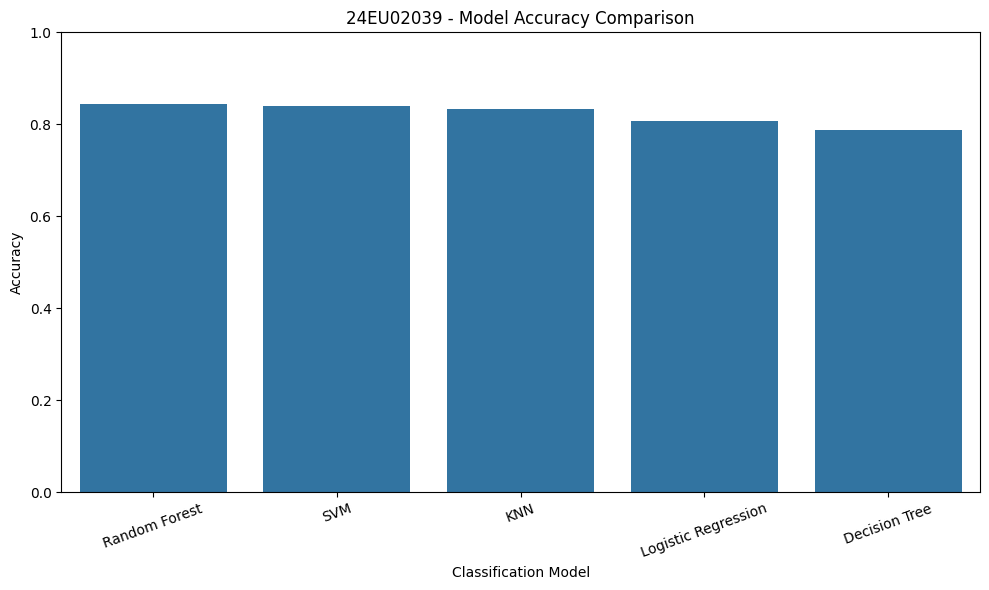

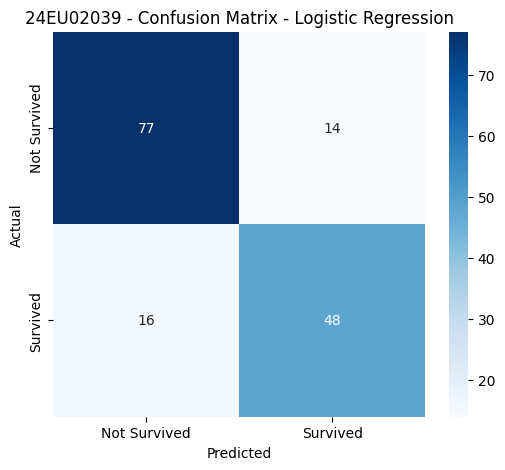

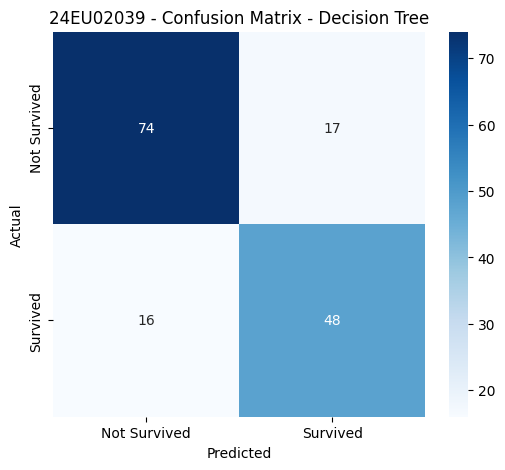

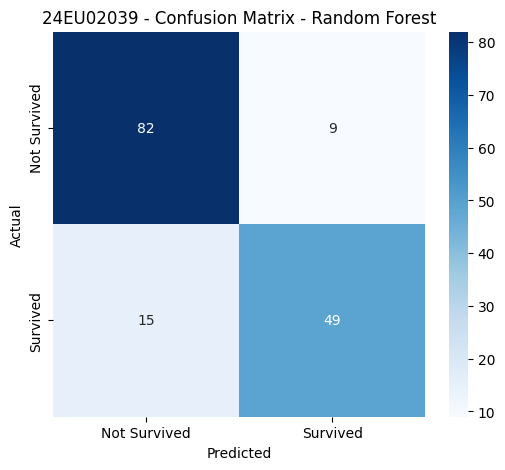

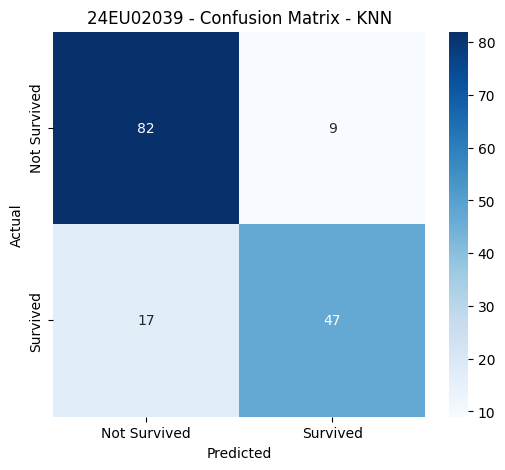

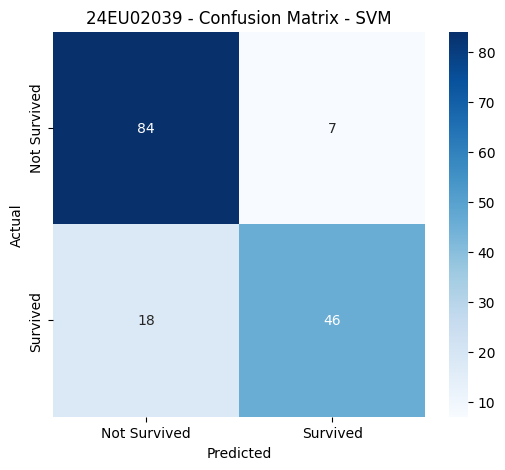



CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

Not Survived       0.83      0.85      0.84        91
    Survived       0.77      0.75      0.76        64

    accuracy                           0.81       155
   macro avg       0.80      0.80      0.80       155
weighted avg       0.81      0.81      0.81       155



CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

Not Survived       0.82      0.81      0.82        91
    Survived       0.74      0.75      0.74        64

    accuracy                           0.79       155
   macro avg       0.78      0.78      0.78       155
weighted avg       0.79      0.79      0.79       155



CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

Not Survived       0.85      0.90      0.87        91
    Survived       0.84      0.77      0.80        64

    accuracy                           0.85       155
  

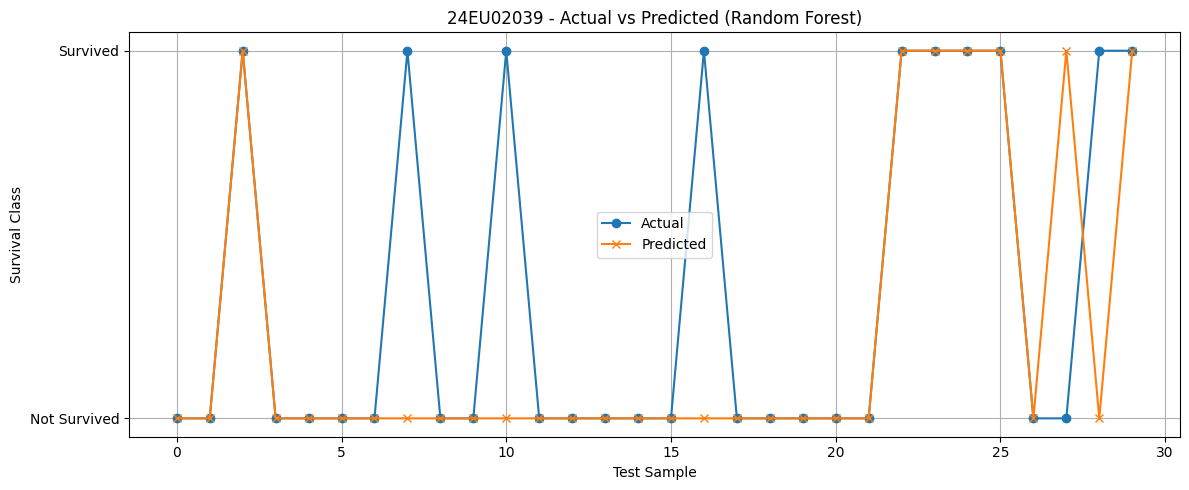



                    FINAL RESULTS
              Model  Accuracy (%)
      Random Forest         84.52
                SVM         83.87
                KNN         83.23
Logistic Regression         80.65
      Decision Tree         78.71


                       CONCLUSION

The Titanic dataset was used to perform a binary classification
task where the target variable was 'survived'.

Target Classes:
0 -> Passenger did not survive
1 -> Passenger survived

The following classification algorithms were implemented:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)

The data was preprocessed by:
- Handling missing values
- Encoding categorical variables
- Creating family_size and is_alone features
- Removing duplicate records
- Splitting the data into training and testing sets
- Applying feature scaling where required

Best performing model:
Random Forest

Best accuracy:
84.52%

Therefore, Random Forest achieved the high

In [2]:
# ============================================================
#          TITANIC DATASET - CLASSIFICATION TASK
#          Register Number: 24EU02039
#          Google Colab - Single Code
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("             TITANIC CLASSIFICATION TASK")
print("                  Register No: 24EU02039")
print("=" * 70)


# ============================================================
# 2. LOAD TITANIC DATASET
# ============================================================

df = sns.load_dataset('titanic')

print("\n1. DATASET")
print("-" * 50)
print(df.head())

print("\nDataset Shape:", df.shape)


# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Remove unnecessary columns
df.drop(
    columns=['deck', 'alive', 'embark_town'],
    inplace=True,
    errors='ignore'
)

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Encode sex
df['sex'] = df['sex'].map({
    'male': 0,
    'female': 1
})

# Encode embarked
df = pd.get_dummies(
    df,
    columns=['embarked'],
    drop_first=True,
    dtype=int
)

# Encode 'class' and 'who' columns
df = pd.get_dummies(
    df,
    columns=['class', 'who'],
    drop_first=True,
    dtype=int
)

# Convert boolean columns to integers
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)


# Remove duplicate records
df.drop_duplicates(inplace=True)

print("\n2. PREPROCESSED DATA")
print("-" * 50)
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop('survived', axis=1)
y = df['survived']

print("\n3. FEATURES")
print("-" * 50)
print(X.columns.tolist())

print("\nTarget Variable: survived")


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n4. TRAIN-TEST SPLIT")
print("-" * 50)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ============================================================
# 6. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n5. FEATURE SCALING COMPLETED")
print("-" * 50)


# ============================================================
# 7. CREATE CLASSIFICATION MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel='rbf',
        random_state=42
    )
}


# ============================================================
# 8. TRAIN MODELS AND CALCULATE ACCURACY
# ============================================================

results = []

predictions = {}

print("\n6. MODEL ACCURACY")
print("-" * 50)

for name, model in models.items():

    # Scale-sensitive models use scaled data
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    predictions[name] = y_pred

    print(f"{name:<25} : {accuracy * 100:.2f}%")


# ============================================================
# 9. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n7. MODEL COMPARISON")
print("-" * 50)
print(results_df)


# ============================================================
# 10. GRAPH - MODEL ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.title('24EU02039 - Model Accuracy Comparison')
plt.xlabel('Classification Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ============================================================
# 11. CONFUSION MATRICES
# ============================================================

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Survived', 'Survived'],
        yticklabels=['Not Survived', 'Survived']
    )

    plt.title(f'24EU02039 - Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# ============================================================
# 12. CLASSIFICATION REPORTS
# ============================================================

for name, y_pred in predictions.items():

    print("\n")
    print("=" * 70)
    print(f"CLASSIFICATION REPORT - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'Not Survived',
                'Survived'
            ]
        )
    )


# ============================================================
# 13. FIND BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']

print("\n")
print("=" * 70)
print("                    BEST MODEL")
print("=" * 70)

print("Best Model       :", best_model_name)
print("Best Accuracy    :", round(best_accuracy * 100, 2), "%")


# ============================================================
# 14. ACTUAL VS PREDICTED VALUES
# ============================================================

best_predictions = predictions[best_model_name]

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_predictions
})

print("\n8. ACTUAL VS PREDICTED VALUES")
print("-" * 50)
print(comparison.head(20))


# ============================================================
# 15. GRAPH - ACTUAL VS PREDICTED
# ============================================================

comparison_sample = comparison.head(30)

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(comparison_sample)),
    comparison_sample['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    range(len(comparison_sample)),
    comparison_sample['Predicted'],
    marker='x',
    label='Predicted'
)

plt.title(
    f'24EU02039 - Actual vs Predicted ({best_model_name})'
)

plt.xlabel('Test Sample')
plt.ylabel('Survival Class')
plt.yticks([0, 1], ['Not Survived', 'Survived'])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 16. FINAL RESULTS TABLE
# ============================================================

print("\n")
print("=" * 70)
print("                    FINAL RESULTS")
print("=" * 70)

final_results = results_df.copy()

final_results['Accuracy (%)'] = (
    final_results['Accuracy'] * 100
).round(2)

final_results = final_results[
    ['Model', 'Accuracy (%)']
]

print(final_results.to_string(index=False))


# ============================================================
# 17. CONCLUSION
# ============================================================

print("\n")
print("=" * 70)
print("                       CONCLUSION")
print("=" * 70)

print(f"""
The Titanic dataset was used to perform a binary classification
task where the target variable was 'survived'.

Target Classes:
0 -> Passenger did not survive
1 -> Passenger survived

The following classification algorithms were implemented:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)

The data was preprocessed by:
- Handling missing values
- Encoding categorical variables
- Creating family_size and is_alone features
- Removing duplicate records
- Splitting the data into training and testing sets
- Applying feature scaling where required

Best performing model:
{best_model_name}

Best accuracy:
{best_accuracy * 100:.2f}%

Therefore, {best_model_name} achieved the highest accuracy
among the classification algorithms tested on this dataset.
""")

print("=" * 70)
print("       TITANIC CLASSIFICATION COMPLETED SUCCESSFULLY")
print("                    24EU02039")
print("=" * 70)